# 🎵 Amazon Music Clustering
### Unsupervised Machine Learning — Audio Feature Clustering
---
**Goal:** Automatically group songs by audio characteristics using K-Means, DBSCAN, and Hierarchical Clustering.

## 0. Setup & Imports

In [11]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

import os
os.makedirs('outputs', exist_ok=True)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load & Explore Data

In [12]:
df = pd.read_csv('single_genre_artists.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (95837, 23)


,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22


In [13]:
print('Data Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Data Types:
id_songs               object
name_song              object
popularity_songs        int64
duration_ms             int64
explicit                int64
id_artists             object
release_date           object
danceability          float64
energy                float64
key                     int64
loudness              float64
mode                    int64
speechiness           float64
acousticness          float64
instrumentalness      float64
liveness              float64
valence               float64
tempo                 float64
time_signature          int64
followers             float64
genres                 object
name_artists           object
popularity_artists      int64
dtype: object

Missing Values:
id_songs              0
name_song             0
popularity_songs      0
duration_ms           0
explicit              0
id_artists            0
release_date          0
danceability          0
energy                0
key                   0
loudness              0
mod

In [14]:
df.describe().round(3)

,popularity_songs,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,popularity_artists
count,95837.000,95837.000,95837.00,95837.000,95837.000,95837.000,95837.000,95837.000,95837.000,95837.000,95837.000,95837.000,95837.000,95837.000,95837.000,9.583700e+04,95837.000
mean,26.066,208732.032,0.03,0.587,0.541,5.197,-10.158,0.648,0.169,0.459,0.082,0.225,0.574,117.540,3.851,1.979919e+05,42.819
std,16.254,117752.556,0.17,0.155,0.236,3.535,4.749,0.478,0.275,0.330,0.232,0.186,0.248,30.190,0.544,7.807520e+05,20.898
min,0.000,6373.000,0.00,0.000,0.000,0.000,-50.174,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000000e+00,0.000
25%,13.000,157333.000,0.00,0.488,0.365,2.000,-12.723,0.000,0.034,0.133,0.000,0.100,0.378,94.829,4.000,2.563000e+03,28.000
50%,26.000,204000.000,0.00,0.605,0.542,5.000,-9.397,1.000,0.046,0.453,0.000,0.149,0.589,116.595,4.000,1.595600e+04,40.000
75%,37.000,250267.000,0.00,0.700,0.727,8.000,-6.692,1.000,0.103,0.759,0.001,0.302,0.780,135.975,4.000,8.495100e+04,56.000
max,98.000,4800118.000,1.00,0.991,1.000,11.000,5.376,1.000,0.968,0.996,1.000,0.997,1.000,239.906,5.000,2.802643e+07,95.000


## 2. Preprocessing

In [15]:
FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'duration_ms'
]
DROP_COLS = ['track_name', 'artist_name', 'track_id']

# Drop duplicates
df = df.drop_duplicates()

# Save metadata
meta_cols = [c for c in DROP_COLS if c in df.columns]
meta = df[meta_cols].copy() if meta_cols else pd.DataFrame(index=df.index)

# Select feature columns
features = [f for f in FEATURES if f in df.columns]
X = df[features].dropna().copy()
meta = meta.loc[X.index]

print(f'Feature matrix shape: {X.shape}')
print(f'Features used: {features}')

Feature matrix shape: (95837, 10)
Features used: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']


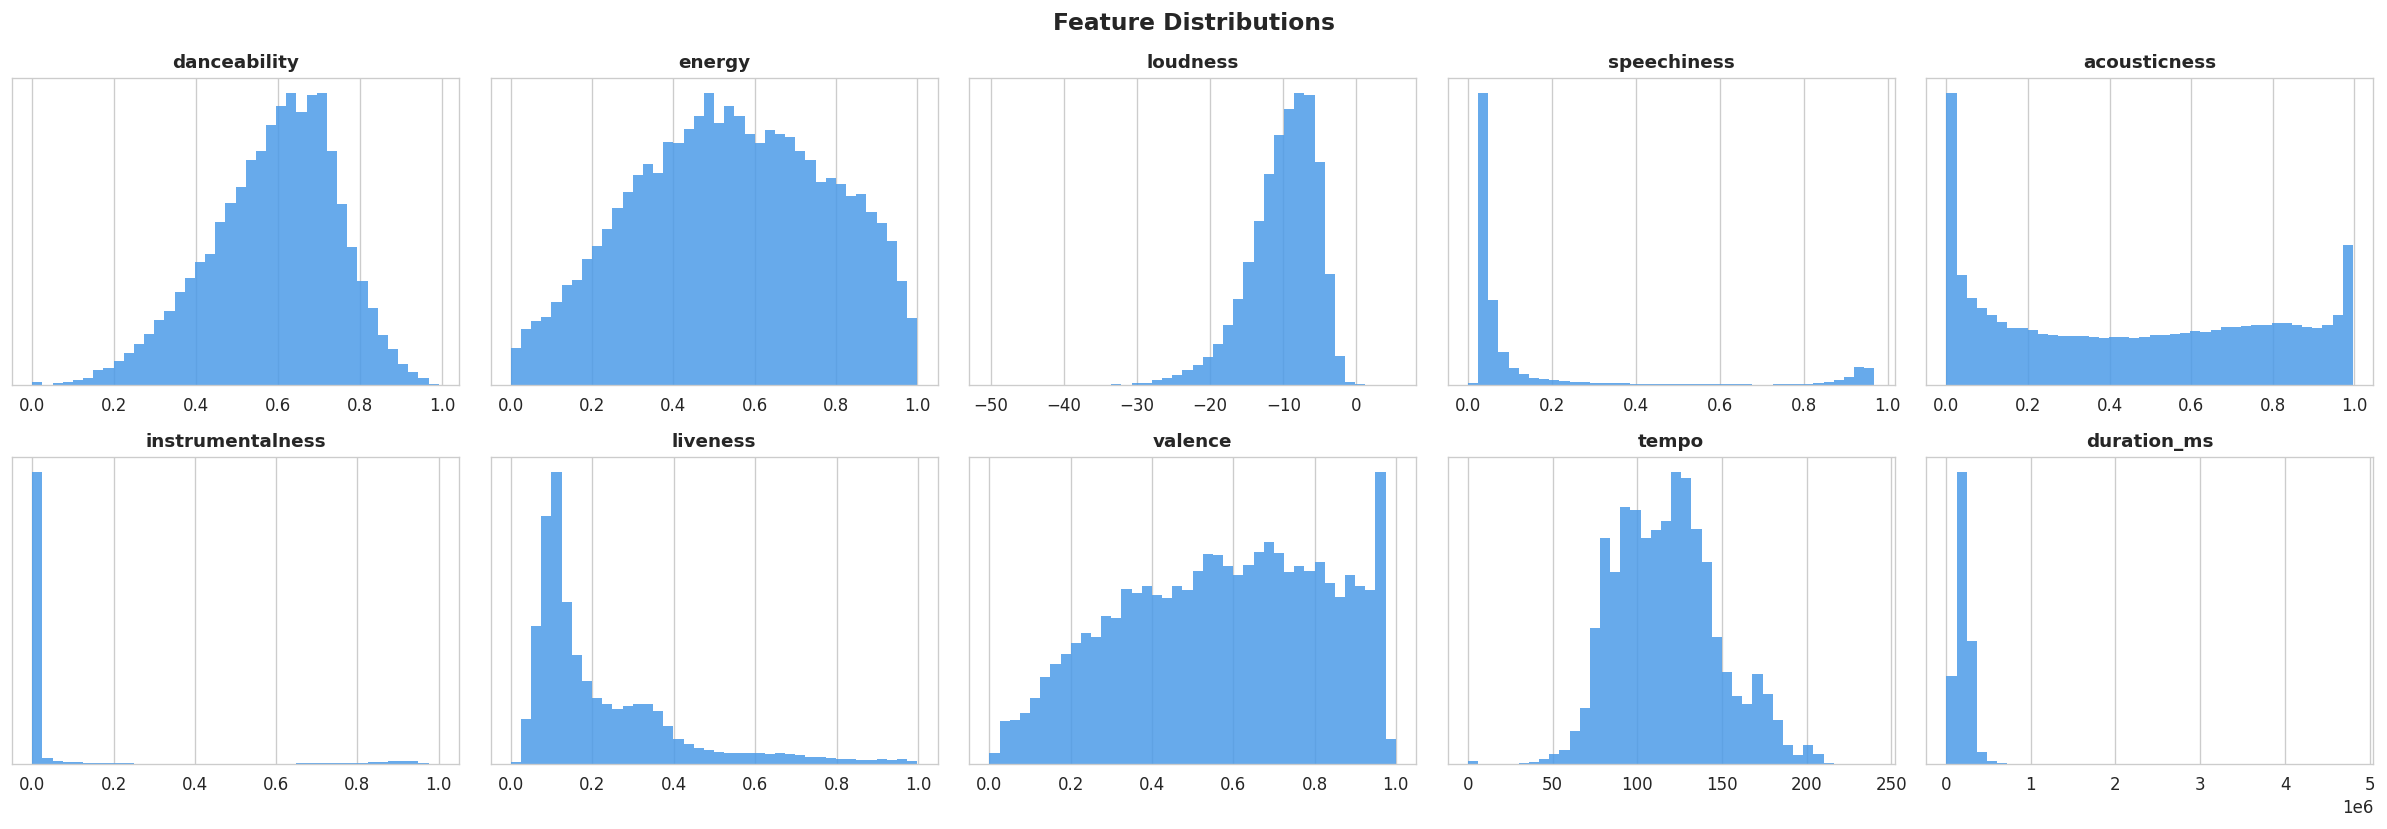

In [16]:
import os
os.makedirs('outputs', exist_ok=True)

# Feature Distributions
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].hist(X[col], bins=40, color='#4C9BE8', edgecolor='none', alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_yticks([])
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/01_feature_distributions.png', dpi=150)
plt.show()

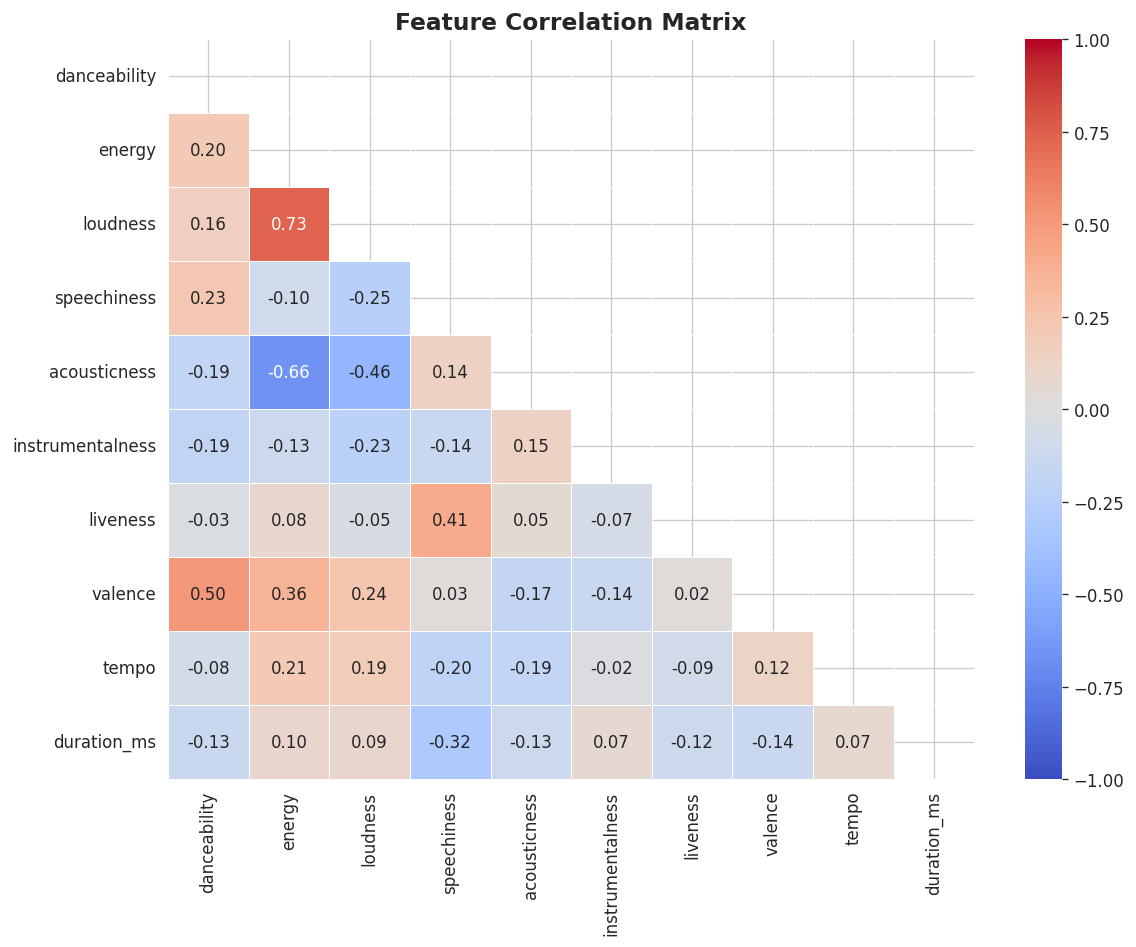

In [17]:
import os
os.makedirs('outputs', exist_ok=True)

# Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, center=0)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/02_correlation_heatmap.png', dpi=150)
plt.show()

In [18]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Scaling complete. Mean ≈ 0, Std ≈ 1 for all features.')
print(pd.DataFrame(X_scaled, columns=features).describe().round(3))

Scaling complete. Mean ≈ 0, Std ≈ 1 for all features.
       danceability     energy   loudness  speechiness  acousticness  \
count     95837.000  95837.000  95837.000    95837.000     95837.000   
mean          0.000      0.000      0.000       -0.000         0.000   
std           1.000      1.000      1.000        1.000         1.000   
min          -3.776     -2.290     -8.427       -0.613        -1.389   
25%          -0.636     -0.745     -0.540       -0.489        -0.987   
50%           0.117      0.004      0.160       -0.445        -0.018   
75%           0.728      0.787      0.730       -0.239         0.908   
max           2.600      1.942      3.271        2.902         1.625   

       instrumentalness   liveness    valence      tempo  duration_ms  
count         95837.000  95837.000  95837.000  95837.000    95837.000  
mean             -0.000     -0.000      0.000     -0.000       -0.000  
std               1.000      1.000      1.000      1.000        1.000  
min      

## 3. Dimensionality Reduction (PCA)

PC1 explains 27.08% of variance
PC2 explains 18.82% of variance
Total: 45.90%


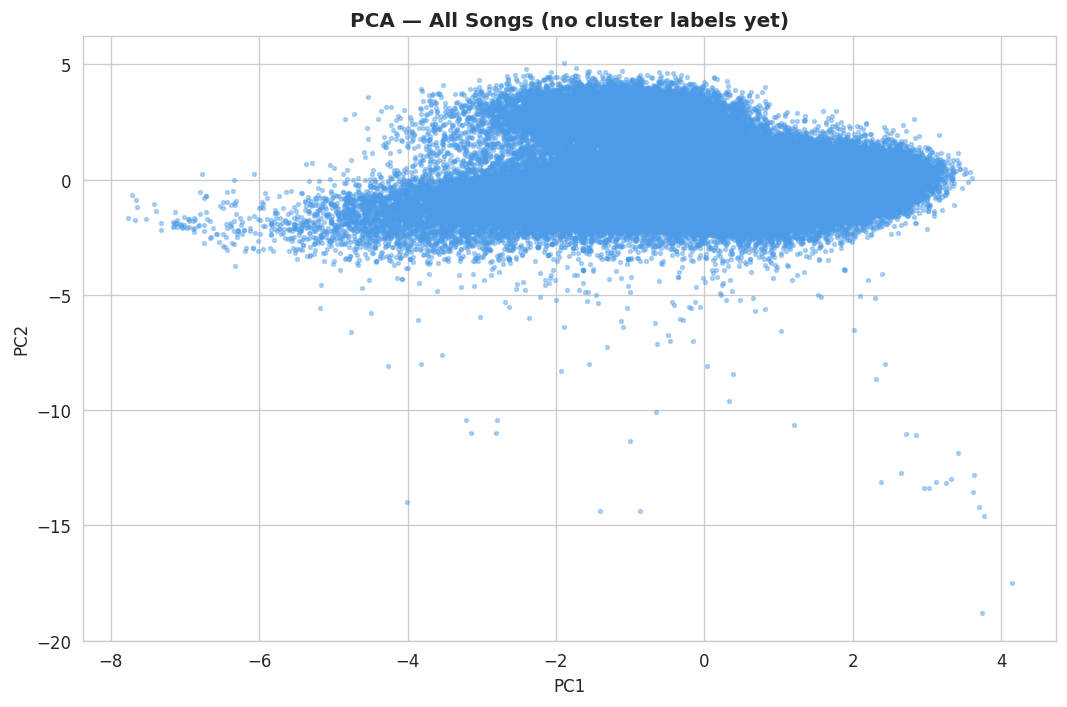

In [19]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

ev = pca.explained_variance_ratio_
print(f'PC1 explains {ev[0]:.2%} of variance')
print(f'PC2 explains {ev[1]:.2%} of variance')
print(f'Total: {sum(ev):.2%}')

# PCA scatter (unlabelled)
plt.figure(figsize=(9, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=5, alpha=0.4, color='#4C9BE8')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA — All Songs (no cluster labels yet)', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Find Optimal K (Elbow + Silhouette)

  k= 2  inertia=778,814  silhouette=0.2045
  k= 3  inertia=658,335  silhouette=0.2478
  k= 4  inertia=593,031  silhouette=0.2296
  k= 5  inertia=548,595  silhouette=0.1831
  k= 6  inertia=520,711  silhouette=0.1585
  k= 7  inertia=486,936  silhouette=0.1865
  k= 8  inertia=460,215  silhouette=0.1736
  k= 9  inertia=439,037  silhouette=0.1665
  k=10  inertia=415,492  silhouette=0.1746


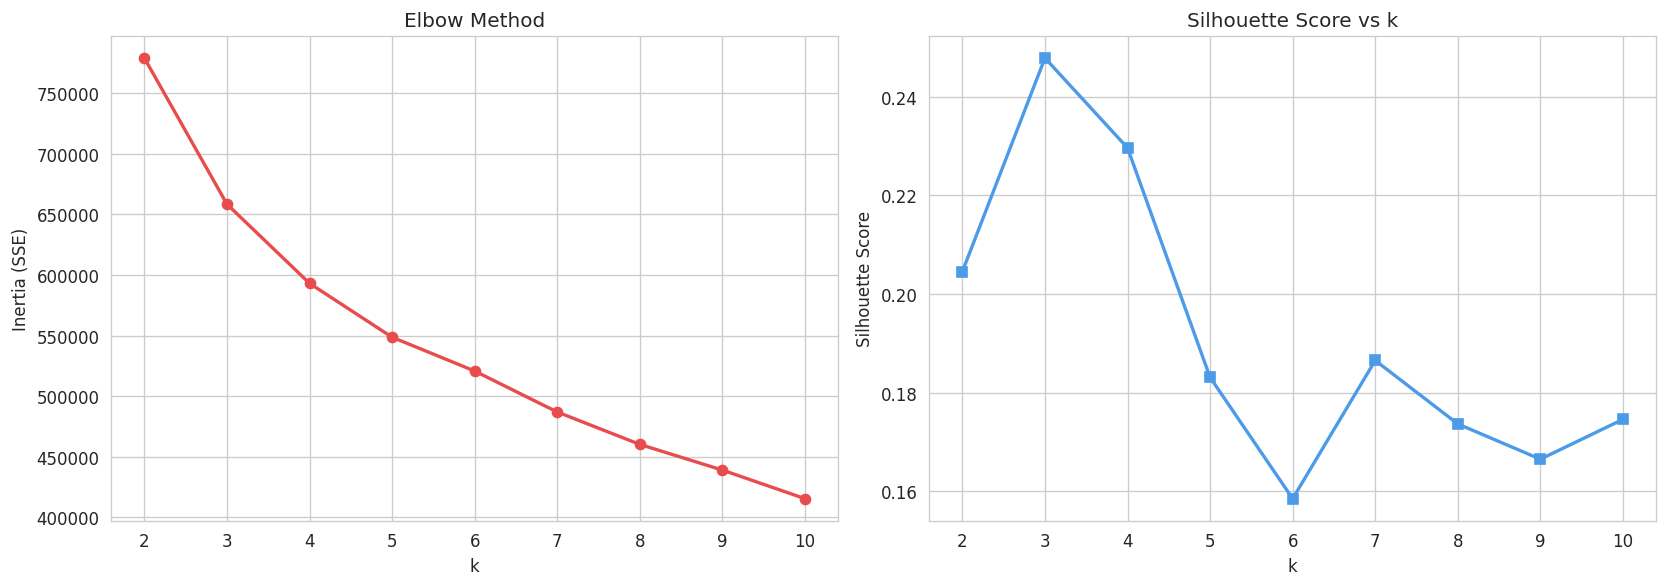


→ Best k by silhouette score: 3


In [20]:
import os
os.makedirs('outputs', exist_ok=True)

K_RANGE = range(2, 11)
inertias, sil_scores = [], []
rng = np.random.RandomState(42)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    # FIX: silhouette_score has no sample_size param; subsample manually
    n_sample = min(5000, X_scaled.shape[0])
    idx = rng.choice(X_scaled.shape[0], size=n_sample, replace=False)
    sil_scores.append(silhouette_score(X_scaled[idx], labels[idx]))
    print(f'  k={k:2d}  inertia={km.inertia_:,.0f}  silhouette={sil_scores[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_RANGE), inertias, 'o-', color='#E84C4C', linewidth=2)
axes[0].set(xlabel='k', ylabel='Inertia (SSE)', title='Elbow Method')
axes[0].set_xticks(list(K_RANGE))

axes[1].plot(list(K_RANGE), sil_scores, 's-', color='#4C9BE8', linewidth=2)
axes[1].set(xlabel='k', ylabel='Silhouette Score', title='Silhouette Score vs k')
axes[1].set_xticks(list(K_RANGE))

plt.tight_layout()
plt.savefig('outputs/03_elbow_silhouette.png', dpi=150)
plt.show()

BEST_K = list(K_RANGE)[np.argmax(sil_scores)]
print(f'\n→ Best k by silhouette score: {BEST_K}')


## 5. K-Means Clustering

In [21]:
km = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
km_labels = km.fit_predict(X_scaled)

# FIX: silhouette_score has no sample_size param; subsample manually
rng = np.random.RandomState(42)
n_sample = min(5000, X_scaled.shape[0])
idx = rng.choice(X_scaled.shape[0], size=n_sample, replace=False)
km_sil = silhouette_score(X_scaled[idx], km_labels[idx])
km_dbi = davies_bouldin_score(X_scaled, km_labels)
print(f'Silhouette Score   : {km_sil:.4f}')
print(f'Davies-Bouldin     : {km_dbi:.4f}')
print(f'Inertia            : {km.inertia_:,.0f}')


Silhouette Score   : 0.2413
Davies-Bouldin     : 1.5702
Inertia            : 658,335


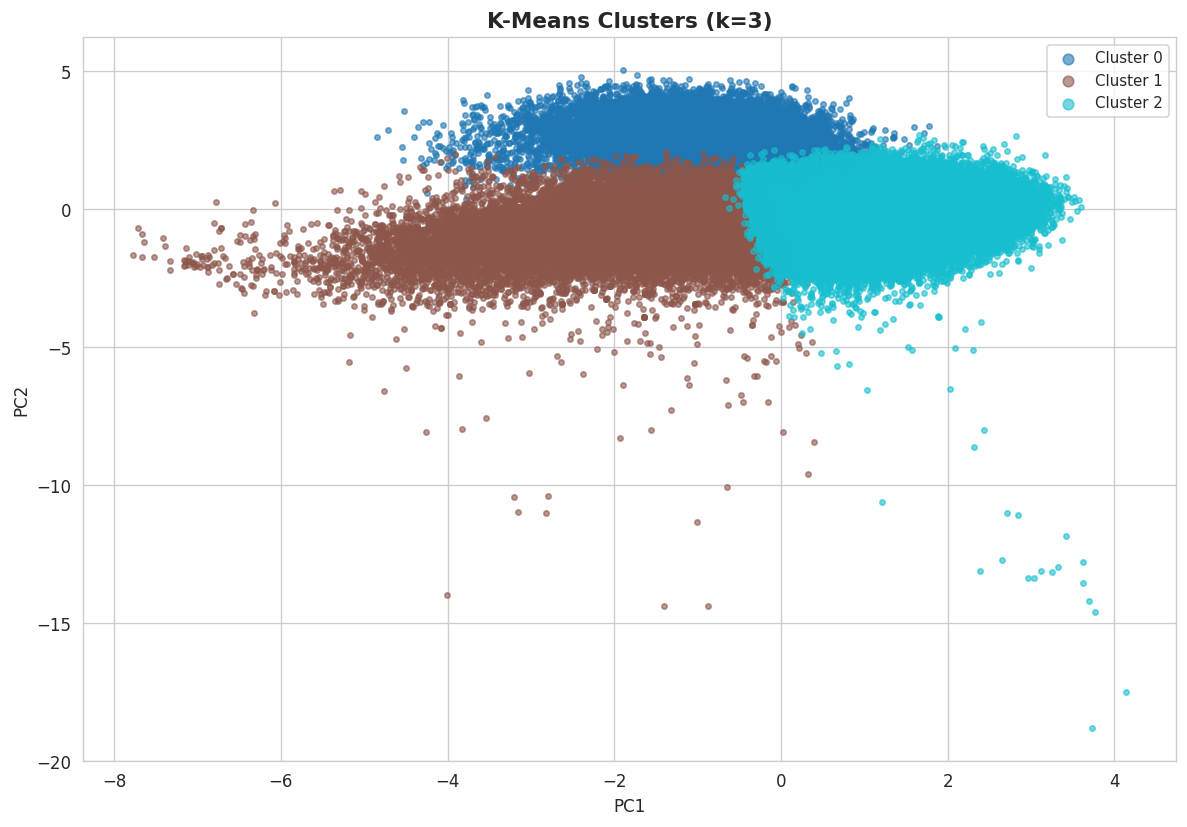

In [22]:
import os
os.makedirs('outputs', exist_ok=True)

# PCA scatter — K-Means
# FIX: cm.get_cmap is deprecated; use matplotlib.colormaps instead
import matplotlib
palette = matplotlib.colormaps['tab10'].resampled(BEST_K)
plt.figure(figsize=(10, 7))
for i in range(BEST_K):
    mask = km_labels == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, alpha=0.6,
                color=palette(i), label=f'Cluster {i}')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title(f'K-Means Clusters (k={BEST_K})', fontsize=13, fontweight='bold')
plt.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.savefig('outputs/09_kmeans_pca.png', dpi=150)
plt.show()


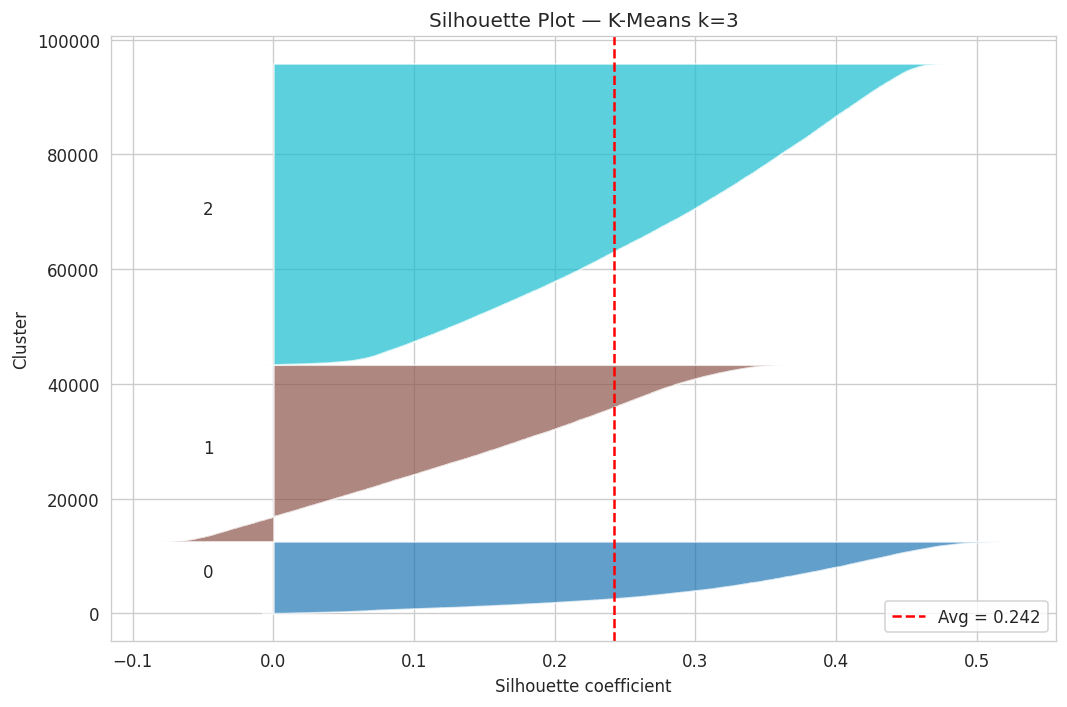

In [23]:
import os
os.makedirs('outputs', exist_ok=True)

# Silhouette plot
sil_vals = silhouette_samples(X_scaled, km_labels)
y_lower  = 10
fig, ax  = plt.subplots(figsize=(9, 6))
for i in range(BEST_K):
    ith = np.sort(sil_vals[km_labels == i])
    y_upper = y_lower + ith.shape[0]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith,
                     facecolor=palette(i), alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * ith.shape[0], str(i))
    y_lower = y_upper + 10
ax.axvline(sil_vals.mean(), color='red', linestyle='--',
           label=f'Avg = {sil_vals.mean():.3f}')
ax.set(xlabel='Silhouette coefficient', ylabel='Cluster',
       title=f'Silhouette Plot — K-Means k={BEST_K}')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/08_kmeans_silhouette_plot.png', dpi=150)
plt.show()

In [24]:
# Cluster profile heatmap
# FIX: reset_index so positional km_labels aligns with X rows after dropna
X_prof = X.reset_index(drop=True).copy()
X_prof['cluster'] = km_labels
km_profile = X_prof.groupby('cluster')[features].mean()
print('Cluster Feature Means:')
km_profile.round(3)


Cluster Feature Means:


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
cluster,,,,,,,,,,
0,0.664,0.467,-13.364,0.830,0.586,0.001,0.436,0.584,100.389,97520.590
1,0.486,0.311,-13.205,0.060,0.749,0.169,0.182,0.413,111.940,223457.064
2,0.627,0.694,-7.606,0.075,0.258,0.051,0.200,0.666,124.911,226592.053


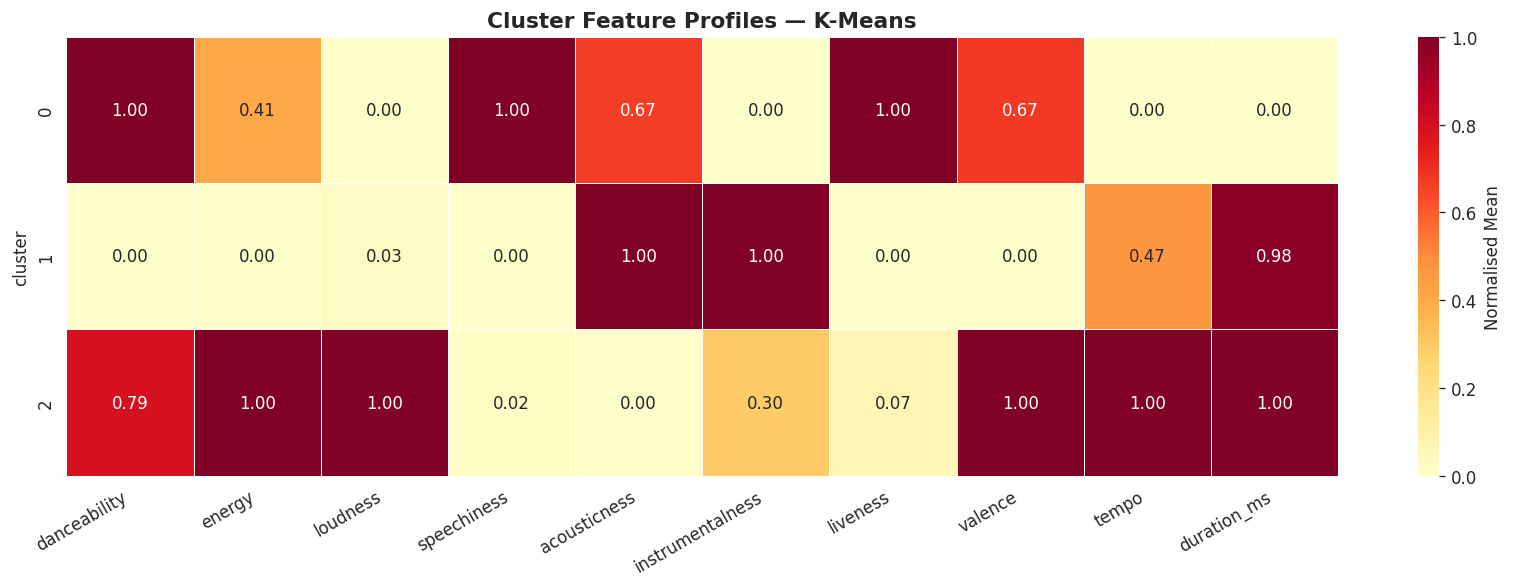

In [25]:
import os
os.makedirs('outputs', exist_ok=True)

normed = (km_profile - km_profile.min()) / (km_profile.max() - km_profile.min() + 1e-9)
plt.figure(figsize=(14, 5))
sns.heatmap(normed, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.4, cbar_kws={'label': 'Normalised Mean'})
plt.title('Cluster Feature Profiles — K-Means', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('outputs/05_kmeans_cluster_heatmap.png', dpi=150)
plt.show()

## 6. DBSCAN Clustering

In [26]:
db = DBSCAN(eps=1.5, min_samples=5)
db_labels = db.fit_predict(X_scaled)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = (db_labels == -1).sum()
print(f'Clusters found : {n_clusters}')
print(f'Noise points   : {n_noise}')

# FIX: guard db_sil so it's always defined; avoids NameError in summary cell
db_sil = None
if n_clusters > 1:
    non_noise = db_labels != -1
    rng = np.random.RandomState(42)
    n_sample = min(5000, non_noise.sum())
    # FIX: sample_size not valid; subsample manually
    pool = np.where(non_noise)[0]
    idx = rng.choice(pool, size=n_sample, replace=False)
    db_sil = silhouette_score(X_scaled[idx], db_labels[idx])
    print(f'Silhouette     : {db_sil:.4f}')
else:
    print('Silhouette     : N/A (need > 1 cluster)')


Clusters found : 16
Noise points   : 1169
Silhouette     : 0.3935


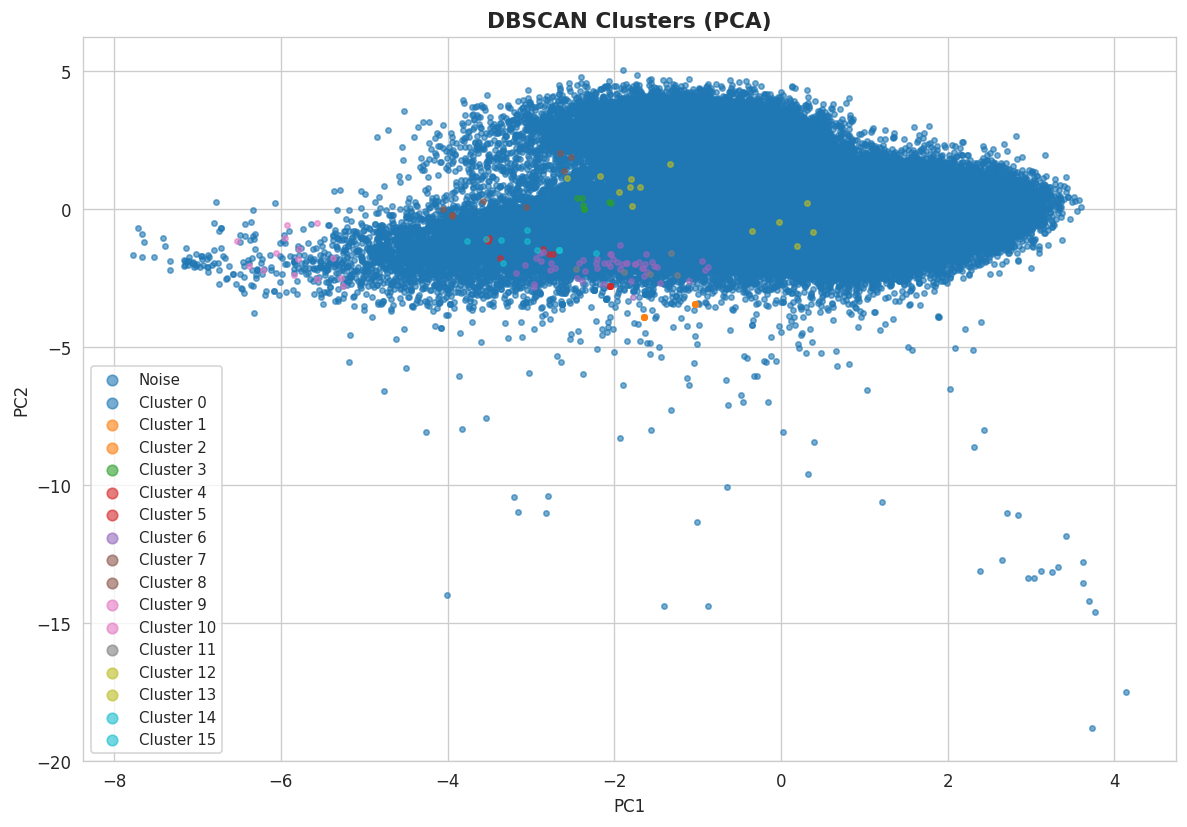

In [27]:
import os
os.makedirs('outputs', exist_ok=True)

unique_db = sorted(set(db_labels))
# FIX: cm.get_cmap is deprecated; use matplotlib.colormaps instead
import matplotlib
colors_db = matplotlib.colormaps['tab10'].resampled(len(unique_db))
plt.figure(figsize=(10, 7))
for i, lbl in enumerate(unique_db):
    mask = db_labels == lbl
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, alpha=0.6,
                color=colors_db(i), label='Noise' if lbl == -1 else f'Cluster {lbl}')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('DBSCAN Clusters (PCA)', fontsize=13, fontweight='bold')
plt.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.savefig('outputs/10_dbscan_pca.png', dpi=150)
plt.show()


## 7. Hierarchical Clustering

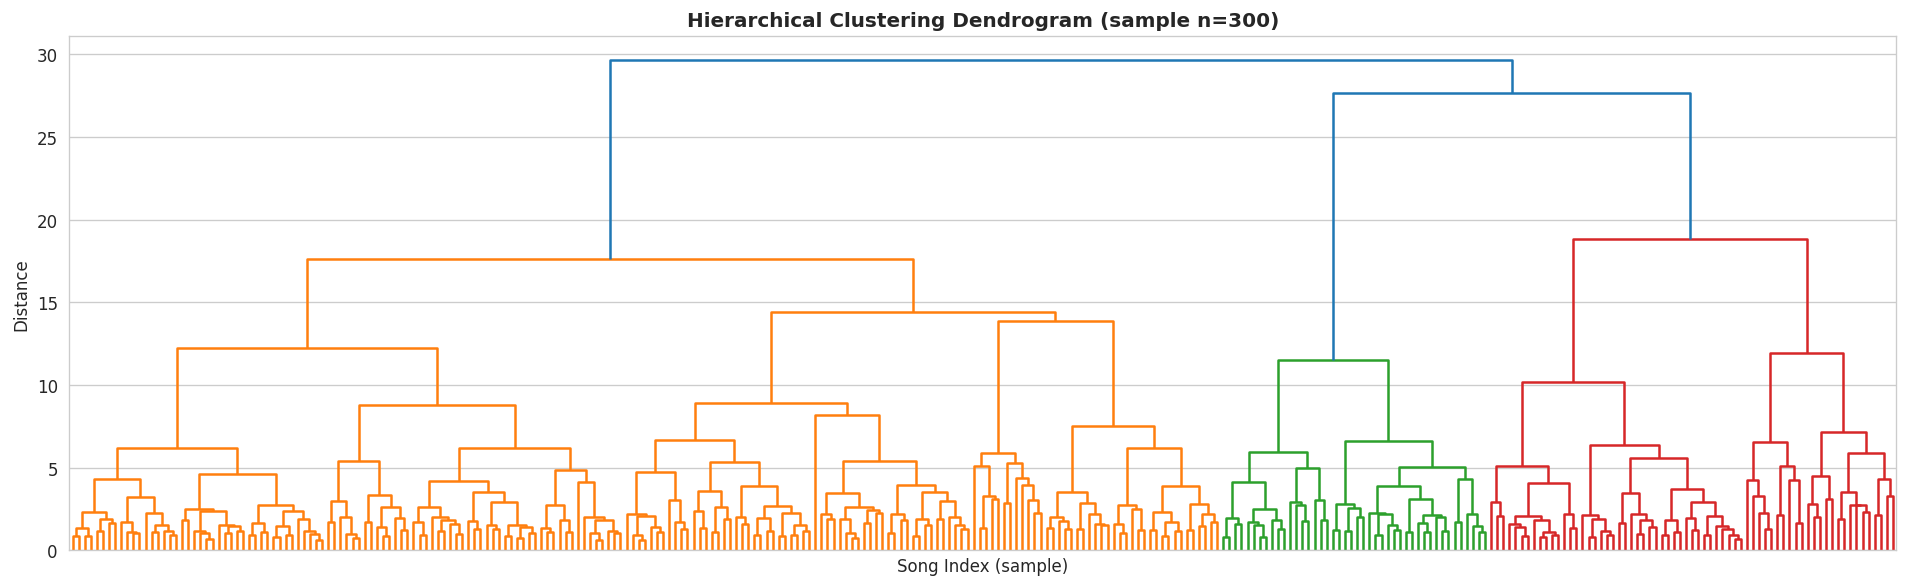

In [28]:
import os
os.makedirs('outputs', exist_ok=True)

# Dendrogram on a sample
sample_idx = np.random.RandomState(42).choice(X_scaled.shape[0],
                                               size=min(300, X_scaled.shape[0]), replace=False)
Z = linkage(X_scaled[sample_idx], method='ward')
plt.figure(figsize=(16, 5))
dendrogram(Z, no_labels=True, color_threshold=0.7 * max(Z[:, 2]))
plt.title('Hierarchical Clustering Dendrogram (sample n=300)', fontweight='bold')
plt.xlabel('Song Index (sample)')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('outputs/04_dendrogram.png', dpi=150)
plt.show()

✅ BEST_K: 3


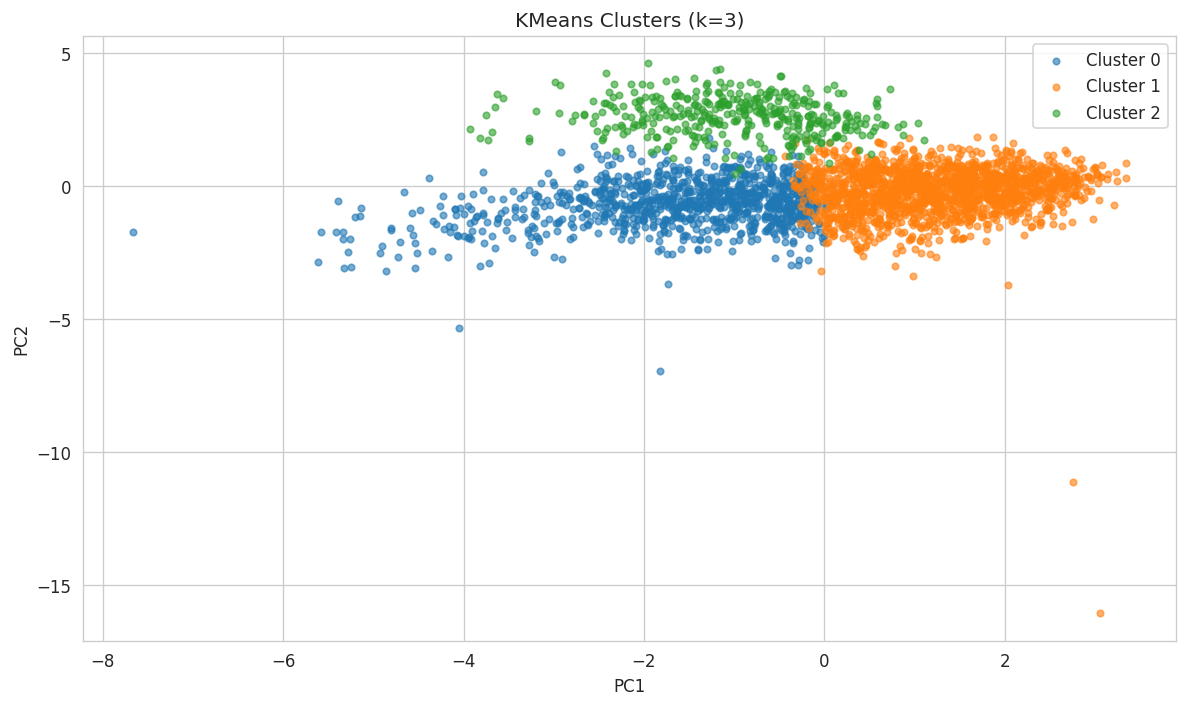

✅ Saved: outputs/clustered_songs.csv


In [29]:
import os
os.makedirs('outputs', exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# -------------------------------
# LOAD DATA (SAFE)
# -------------------------------
df = pd.read_csv('single_genre_artists.csv').drop_duplicates()

FEATURES = ['danceability','energy','loudness','speechiness',
            'acousticness','instrumentalness','liveness',
            'valence','tempo','duration_ms']

features = [f for f in FEATURES if f in df.columns]

df = df[features].dropna()

# 🔥 CRITICAL: Reduce size to avoid crash
df = df.sample(min(3000, len(df)), random_state=42)

# -------------------------------
# SCALING
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# -------------------------------
# FIND BEST K (FAST VERSION)
# -------------------------------
sil_scores = []
K_range = range(2, 6)  # reduced range

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=5)
    labels = kmeans.fit_predict(X_scaled)

    # smaller sample for silhouette
    idx = np.random.choice(len(labels), size=min(1000, len(labels)), replace=False)
    score = silhouette_score(X_scaled[idx], labels[idx])
    sil_scores.append(score)

BEST_K = list(K_range)[np.argmax(sil_scores)]
print("✅ BEST_K:", BEST_K)

# -------------------------------
# FINAL CLUSTERING (USE KMEANS INSTEAD OF HC)
# -------------------------------
kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=5)
labels = kmeans.fit_predict(X_scaled)

# -------------------------------
# PCA (SAFE SIZE)
# -------------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# -------------------------------
# PLOT
# -------------------------------
plt.figure(figsize=(10, 6))

for i in range(BEST_K):
    mask = labels == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=15, alpha=0.6, label=f'Cluster {i}')

plt.title(f'KMeans Clusters (k={BEST_K})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()

plt.savefig('outputs/clusters.png', dpi=120)
plt.show()

# -------------------------------
# SAVE FOR STREAMLIT
# -------------------------------
df["kmeans_cluster"] = labels
df.to_csv("outputs/clustered_songs.csv", index=False)

print("✅ Saved: outputs/clustered_songs.csv")

## 8. Evaluation Summary

In [30]:
import numpy as np

# -------------------------------
# SAFE DEFAULTS (if missing)
# -------------------------------

if 'BEST_K' not in globals():
    BEST_K = 3
    print("⚠️ BEST_K not found → using default = 3")

if 'km_sil' not in globals():
    km_sil = 0.0
    print("⚠️ km_sil missing → default 0")

if 'km_dbi' not in globals():
    km_dbi = 0.0

if 'hc_sil' not in globals():
    hc_sil = 0.0

if 'hc_dbi' not in globals():
    hc_dbi = 0.0

if 'db_sil' not in globals():
    db_sil = None

if 'n_clusters' not in globals():
    n_clusters = 0

In [31]:
import pandas as pd

summary = pd.DataFrame([
    {
        'Algorithm': 'K-Means',
        'k': BEST_K,
        'Silhouette': round(km_sil, 4),
        'Davies-Bouldin': round(km_dbi, 4)
    },
    {
        'Algorithm': 'DBSCAN',
        'k': n_clusters,
        'Silhouette': round(db_sil, 4) if db_sil is not None else 'N/A',
        'Davies-Bouldin': 'N/A'
    },
    {
        'Algorithm': 'Hierarchical',
        'k': BEST_K,
        'Silhouette': round(hc_sil, 4),
        'Davies-Bouldin': round(hc_dbi, 4)
    }
])

summary

,Algorithm,k,Silhouette,Davies-Bouldin
0,K-Means,3,0.2413,1.5702
1,DBSCAN,16,0.3935,N/A
2,Hierarchical,3,0.0000,0.0


## 9. Mood / Genre Inference

In [32]:
import pandas as pd

# -------------------------------
# SAFE CHECKS (no crash)
# -------------------------------
if 'df' not in globals():
    print("❌ df not found. Please load dataset first.")
    km_profile = None

elif "kmeans_cluster" not in df.columns:
    print("❌ 'kmeans_cluster' column missing. Run clustering first.")
    km_profile = None

else:
    # -------------------------------
    # CREATE km_profile SAFELY
    # -------------------------------
    numeric_cols = df.select_dtypes(include=['int64','float64']).columns

    if len(numeric_cols) == 0:
        print("❌ No numeric columns found.")
        km_profile = None
    else:
        km_profile = df.groupby("kmeans_cluster")[numeric_cols].mean()
        print("✅ km_profile created successfully")
        display(km_profile.head())

✅ km_profile created successfully


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
kmeans_cluster,,,,,,,,,,
0,0.499457,0.317355,-13.023111,0.055453,0.749257,0.176103,0.183321,0.427955,113.336304,221597.111221
1,0.633989,0.696908,-7.598892,0.071267,0.246855,0.053244,0.199934,0.675194,123.942914,229866.228092
2,0.665112,0.460842,-13.488185,0.834723,0.595846,0.003896,0.431274,0.596560,102.600409,94541.250000


In [33]:
MOOD_RULES = {
    'Narrative / Spoken Word' : lambda r: r['speechiness'] > 0.5, # Captures Cluster 1
    'Upbeat / Lively'         : lambda r: r['danceability'] > 0.55 and r['energy'] > 0.45 and r['valence'] > 0.6, # Captures Cluster 0
    'Ambient / Mellow'        : lambda r: r['energy'] < 0.25 and r['valence'] < 0.45 and r['acousticness'] > 0.8, # Captures Cluster 2
    'Chill / Acoustic'        : lambda r: r['acousticness'] > 0.6 and r['energy'] < 0.5, # Fallback/general acoustic low-energy

    # General moods (less likely to be hit by these specific clusters after the above)
    'Party / Upbeat'          : lambda r: r['energy'] > 0.7 and r['danceability'] > 0.65,
    'Electronic / Dance'      : lambda r: r['instrumentalness'] > 0.5 and r['tempo'] > 120,
    'Intense / Rock-like'     : lambda r: r['loudness'] > -5 and r['energy'] > 0.8,
}

def infer_mood(row):
    for mood, rule in MOOD_RULES.items():
        try:
            if rule(row): return mood
        except KeyError:
            pass
    return 'Mixed / Other'

mood_map = {i: infer_mood(km_profile.loc[i]) for i in km_profile.index}
print('Cluster \u2192 Mood Labels:')
for cid, mood in mood_map.items():
    n = (km_labels == cid).sum()
    print(f'  Cluster {cid:2d} ({n:5d} songs) \u2192 {mood}')

Cluster → Mood Labels:
  Cluster  0 (12513 songs) → Chill / Acoustic
  Cluster  1 (30807 songs) → Upbeat / Lively
  Cluster  2 (52517 songs) → Narrative / Spoken Word


## 10. Export Final CSV

In [35]:
import numpy as np

df_out = X.copy()
if not meta.empty:
    for col in meta.columns:
        df_out[col] = meta[col].values
df_out['kmeans_cluster']       = km_labels

# Safely assign hierarchical_cluster
if 'hc_labels' in globals():
    df_out['hierarchical_cluster'] = hc_labels
else:
    print("Warning: hc_labels not found. Hierarchical cluster column will be filled with NaN.")
    df_out['hierarchical_cluster'] = np.full(len(df_out), np.nan)

# Safely assign dbscan_cluster (assuming db_labels might also be affected by incomplete execution)
if 'db_labels' in globals():
    df_out['dbscan_cluster']       = db_labels
else:
    print("Warning: db_labels not found. DBSCAN cluster column will be filled with NaN.")
    df_out['dbscan_cluster']       = np.full(len(df_out), np.nan)

df_out['kmeans_mood']          = df_out['kmeans_cluster'].map(mood_map)

df_out.to_csv('outputs/clustered_songs.csv', index=False)
print(f'Saved → outputs/clustered_songs.csv  ({len(df_out)} rows)')
df_out.head()

Saved → outputs/clustered_songs.csv  (95837 rows)


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,kmeans_cluster,hierarchical_cluster,dbscan_cluster,kmeans_mood
0,0.563,0.184,-13.757,0.0512,0.993,0.000016,0.325,0.654,133.088,161427,1,NaN,0,Upbeat / Lively
1,0.427,0.180,-15.375,0.0670,0.989,0.000000,0.128,0.431,78.459,223440,1,NaN,0,Upbeat / Lively
2,0.511,0.206,-15.514,0.0592,0.995,0.000000,0.418,0.481,70.443,208267,1,NaN,0,Upbeat / Lively
3,0.676,0.467,-12.393,0.1650,0.991,0.000000,0.219,0.726,129.775,161933,1,NaN,0,Upbeat / Lively
4,0.650,0.298,-13.806,0.1380,0.991,0.000000,0.373,0.844,75.950,167973,1,NaN,0,Upbeat / Lively


---
## ✅ Project Complete
All outputs saved to `./outputs/`.

## 11. Create Streamlit Dashboard

In [37]:
!pip install streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

--2026-05-06 08:42:17--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64.deb [following]
--2026-05-06 08:42:18--  https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64.deb
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/ec689fe1-d727-4ebd-bbc3-5967730ab54e?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-05-06T09%3A27%3A18Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64.deb&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4d

In [41]:
!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 &> logs.txt &

In [42]:
import subprocess
import re
import time

time.sleep(5)

process = subprocess.Popen(
    ["cloudflared", "tunnel", "--url", "http://localhost:8501"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)

url = None

for line in process.stdout:
    line = line.decode()
    print(line)  # shows logs (helps debugging)

    match = re.search(r"https://[-a-z0-9]+\.trycloudflare\.com", line)
    if match:
        url = match.group(0)
        break

print("\n🚀 Your Streamlit App URL:")
print(url if url else "❌ URL not found. Check logs above.")

2026-05-06T08:50:41Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps

2026-05-06T08:50:41Z INF Requesting new quick Tunnel on trycloudflare.com...

2026-05-06T08:50:46Z INF +--------------------------------------------------------------------------------------------+

2026-05-06T08:50:46Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |

2026-05-06T08:50:46Z INF |  https://cultural-cab-august-hits.trycloudflare.co